In [12]:
# CELL 1 — Imports
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image


In [13]:
# BLOCK 2 — Settings (edit paths if necessary)
MODEL_PATH = "final_model.h5"      # your saved model file
LABELS_PATH = "labels_map.json"    # created & downloaded from Kaggle
IMAGES_FOLDER = "testingImages"    # folder containing 1.jpg .. 5.jpg
IMAGE_SIZE = (100, 100)            # must match training size
TOP_K = 3                          # show top-3 predictions

# sanity checks
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
if not os.path.exists(LABELS_PATH):
    raise FileNotFoundError(f"labels_map.json not found: {LABELS_PATH}")
if not os.path.isdir(IMAGES_FOLDER):
    raise FileNotFoundError(f"Images folder not found: {IMAGES_FOLDER}")

print("Settings OK.")
print("MODEL_PATH:", MODEL_PATH)
print("LABELS_PATH:", LABELS_PATH)
print("IMAGES_FOLDER:", IMAGES_FOLDER)


Settings OK.
MODEL_PATH: final_model.h5
LABELS_PATH: labels_map.json
IMAGES_FOLDER: testingImages


In [14]:
# BLOCK 3 — Load model and labels_map
model = keras.models.load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)
print("Model input shape:", model.input_shape)

with open(LABELS_PATH, "r") as f:
    labels_map = json.load(f)

# Ensure keys are ints (JSON may have string keys)
labels_map = {int(k): v for k, v in labels_map.items()}
print(f"Loaded labels_map with {len(labels_map)} classes. Example:", dict(list(labels_map.items())[:6]))


Loaded model: final_model.h5
Model input shape: (None, 100, 100, 3)
Loaded labels_map with 228 classes. Example: {0: 'Apple 10', 1: 'Apple 11', 2: 'Apple 12', 3: 'Apple 13', 4: 'Apple 14', 5: 'Apple 17'}


In [15]:
# BLOCK 4 — Helpers
def preprocess_img(path, target_size=IMAGE_SIZE):
    pil = image.load_img(path, target_size=target_size)
    x = image.img_to_array(pil).astype("float32") / 255.0
    x = np.expand_dims(x, axis=0)
    return pil, x

def predict_topk(x, model, k=TOP_K):
    preds = model.predict(x)[0]
    top_idx = preds.argsort()[-k:][::-1]
    top_probs = preds[top_idx]
    return list(zip([int(i) for i in top_idx], [float(p) for p in top_probs]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
--------------------------------------------------
Image: testingImages/1.jpg
Top-1: Orange 1 (index=143) — prob=1.0000
Top-3:
  1. Orange 1 (idx=143) — 1.0000
  2. Pepper Yellow 1 (idx=176) — 0.0000
  3. Apricot 1 (idx=30) — 0.0000


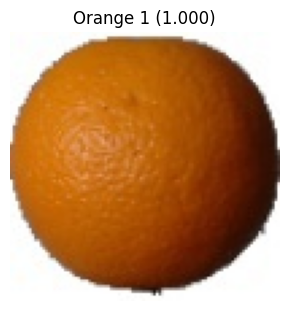

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
--------------------------------------------------
Image: testingImages/2.jpg
Top-1: Kiwi 1 (index=113) — prob=1.0000
Top-3:
  1. Kiwi 1 (idx=113) — 1.0000
  2. Peach Flat 1 (idx=152) — 0.0000
  3. Pineapple Mini 1 (idx=180) — 0.0000


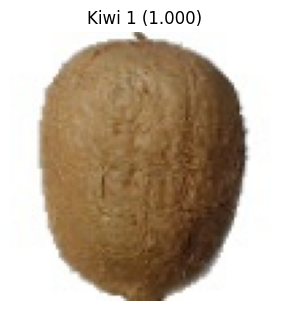

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
--------------------------------------------------
Image: testingImages/3.jpg
Top-1: Banana 1 (index=36) — prob=1.0000
Top-3:
  1. Banana 1 (idx=36) — 1.0000
  2. Cucumber 4 (idx=85) — 0.0000
  3. Banana Lady Finger 1 (idx=39) — 0.0000


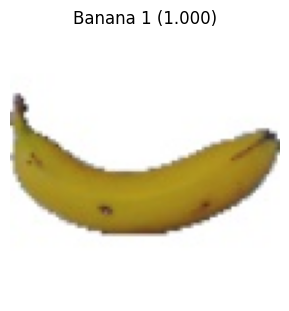

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
--------------------------------------------------
Image: testingImages/4.jpg
Top-1: Blackberrie 1 (index=43) — prob=1.0000
Top-3:
  1. Blackberrie 1 (idx=43) — 1.0000
  2. Blackberrie half rippen 1 (idx=45) — 0.0000
  3. Cucumber 5 (idx=86) — 0.0000


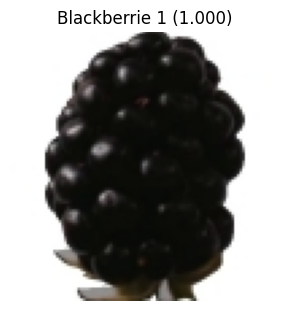

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
--------------------------------------------------
Image: testingImages/5.jpg
Top-1: Apple 10 (index=0) — prob=1.0000
Top-3:
  1. Apple 10 (idx=0) — 1.0000
  2. Apple 8 (idx=11) — 0.0000
  3. Apple Crimson Snow 1 (idx=15) — 0.0000


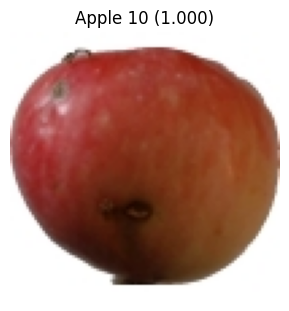

In [16]:
# BLOCK 5 — Predict and display for files 1.jpg .. 5.jpg
for i in range(1, 6):
    img_path = os.path.join(IMAGES_FOLDER, f"{i}.jpg")
    if not os.path.exists(img_path):
        print(f"[WARN] Missing: {img_path}")
        continue

    pil_img, x = preprocess_img(img_path)
    topk = predict_topk(x, model, k=TOP_K)
    top1_idx, top1_prob = topk[0]
    top1_name = labels_map.get(top1_idx, f"Class_{top1_idx}")

    # Print human-readable result
    print("--------------------------------------------------")
    print(f"Image: {img_path}")
    print(f"Top-1: {top1_name} (index={top1_idx}) — prob={top1_prob:.4f}")
    print("Top-%d:" % TOP_K)
    for rank, (idx, prob) in enumerate(topk, start=1):
        name = labels_map.get(idx, f"Class_{idx}")
        print(f"  {rank}. {name} (idx={idx}) — {prob:.4f}")

    # Display image with title
    plt.figure(figsize=(3.5,3.5))
    plt.imshow(pil_img)
    plt.title(f"{top1_name} ({top1_prob:.3f})")
    plt.axis("off")
    plt.show()
